In [1]:
"""
Imports here
"""
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import numpy as np
import random as rd
import Helper as hp
import math as math


# NK Model
This is a notebook to help me visualize and work through Stuart Kaufman's *The Origins of Order: Self-Organization and Selection in Evolution*. **NOT** for use in any actual NK modelling, if you're looking to actually work with NK Models, I recommend [elplatts's](https://github.com/elplatt/nkmodel) version available through the python package repository.

I will be starting with some generation and visualization of small NK models, and some confirmation of claims made by Kaufman about the NK models. 

For the NK model we will want *eventually* to generate a topological map of the fitness landscape, for simplicity of modelling we will be working with the 2 allele toy problem variant.

The NK Model has the following parameters:
- **Necessary**
    - $N$: refers to the number of parts of the system (this can be genes, amino acids in a protein etc)
        - given this the set of total possible genotypes in the ensemble is $2^{N}$ (for the 2 allele toy varient, for any given A it is $A^{N}$) 
    - $K$: refers to the number of epistatic interactions between the parts, that is when assessing the fitness of a given part, what is the average number of other parts that factor into and impact the fitness of the currently considered part
        - this is a point of distinction for the NK model from standard population genetics approaches which confer that each gene contributes independently to the overall fitness (the *N-Locus two-allele additive fitness model*)
        - prior attempts to explain these epistatic interactions include the *multiplicative fitness* model, where genes multiply effects
            - however this approach does not adequately cover the true scope of potential epistatic interactions
            - therefore we will appraoch the modelling from the perspective of trying to capture the statistical features of the range of epistatic interactions by capturing the consequences with a random fitness function
    - $w_{i}$: given assignment of K relevant locus to each gene $i \in N$, we can then assign a list of random weights $w_i \in [0,1]$ for each combination of the $K + 1$ epistatically linked loci. The number of such combinations (that is the length of list of weights for each locus) will be $2^{K+1}$ (for our purposes this list will be the length of the whole ensemble, so we have an easier time managing the weights calculation).

- **Optional**
    - **A**: refers to the number of Alleles for each $N$ part. For simplicity will hold this at 2 alleles so that modelling is possible
    - **I**: this specifies how the $K$ genes are distributed across the $N$ genes (that is the mapping of the interactions) -> Kaufman says this isn't necessary (*verify*)
    - **D**: the dimensionality of the genotype space - reflects the number of 1-mutant neighbours each genotype has in the space ($N(A-1)$ and in the case of our toy scope $N$)

And the following properties/outcomes:
- $W$: this is the overall fitness of the entire genotype defined with the function $W = \frac{1}{N}\displaystyle\sum^{N}_{i=1}w_i$

In [22]:
# Find new one hammond moves from a given position
def new_one_hammonds(genotype:list,
                     seen: list):
    one_hammonds = []
    for i in range(len(genotype)):
        temp = genotype.copy()
        if genotype[i] == 1:
            temp[i] = 0
        elif genotype[i] == 0:
            temp[i] = 1
        value_tuple = tuple(temp)
        if value_tuple not in seen: 
            one_hammonds.append(temp)
            seen.append(value_tuple)
    return one_hammonds, seen


#we need to generate a smaller ensemble for testing, given an initial state as a number, generate subensemble contasining it and all it's neighbours for rounds steps
def generate_ensemble_slice(start: list,
                            N: int,
                            K: int,
                            A: int = 2,
                            rounds: int = 10,
                            players: int = 10):
    ensemble = {}
    ensemble[0] = start 
    rounds_counter = 0
    seen = []
    while rounds_counter < rounds:
        lens = len(ensemble)
        lens2= len(seen)
        copy_ensemble = ensemble.copy()
        for key, value in copy_ensemble.items():
            one_hammonds, seen = new_one_hammonds(value, seen)
            for j in one_hammonds:
                ensemble[len(ensemble)] = j
        rounds_counter+=1        
    return ensemble


# The function below generates weights. It can generate weights preserving the mapping defined in assign_neighbours
# this will return the weight matrix for the ensemble.
def generate_weights(N: int,
                     K: int,
                     ensemble: dict,
                     A: int = 2):
    weights = {}
    K_loci = hp.assign_neighbours(N,K)
    for i in range(N):
        weight_i = []
        neighbours = K_loci[i]
        neighbour_set = {}
        for j in ensemble.keys():
            genotype = ensemble[j]
            temp = []
            present = False
            for n in neighbours:
                temp.append(genotype[n])
            for key, val in neighbour_set.items():
                if val == temp:
                    weight_i.append(key)
                    present = True
            if present == False:
                weight = rd.uniform(0,1)
                neighbour_set[weight] = temp
                weight_i.append(weight)
            elif present == True:
                present = False
            weights[i] = weight_i
    return weights

#The following function calculates the total genotype fitness sum and returns a dictionary containing all the genotypes and their fitness scores
def calculate_fitness(weights: dict,
                     ensemble: dict):
    genotype_fitness = []
    for i in ensemble.keys():
        fitness = 0
        genotype = ensemble[i]
        for j in range(len(weights)):
            fitness += weights[j][i]
        genotype_fitness.append(fitness)
    return genotype_fitness
     

# Visualising Fitness Landscapes
Now that I spent a whole evening setting the above up, we are ready to do visualize all of the great fitness graphs that Kaufman has in store for us. 
The code below takes some starting gene (using a random number generator and then generating the bit string representing it) and then visualizations the trajectory of a number of starting populations evolving from that genome. We will use it to investigate the properties of NK space (we can do so because the evolution of any evolutionary trajectory is ergodic to the larger NK space).

In [19]:
def starting_ensemble(N: int,
                      K: int,
                      A: int = 2,
                      rounds: int = 10,
                      players: int = 10):
    random_genome_number = rd.randint(0,A**N)
    start_genome = hp.generate_bit_strings(random_genome_number, N, A) 
    ensemble = generate_ensemble_slice(start_genome, N, A, rounds = rounds, players = players)
    weights = generate_weights(N, K, ensemble, A)
    fitness = calculate_fitness(weights, ensemble)
    return start_genome, ensemble, fitness



# Here we are gonna try generating a set of one mutant walks from a single genotype and graphing their fitness changes 
# => hopefully this should give us a clearer slice of the dynamics of the fitness landscape (assuming ergodicity) 

    
def one_mutant_scape(N: int,
                     K: int,
                     A: int = 2,
                     rounds:   int = 10,
                     players:  int = 10):

    
    
    # here we initialize the starting genome from which to perform walks and the fitness/paths arrays to store the process
    start_genome, ensemble, fitnesses = starting_ensemble(N, K, A, rounds, players)
    current_genome                    = np.zeros(players, dtype=object)
    fitness_array                     = np.zeros((rounds, players))
    evolution_array                   = np.zeros((players, rounds), dtype=object)

    # populate first step into evolution array, and first fitness in fitness array
    for p in range(players):
        fitness_array[0][p]   = fitnesses[0]
        current_genome[p]     = start_genome.copy()
        evolution_array[p][0] = current_genome[p]
    round_tracker   = 0
    tried_mutations = np.zeros(players)
    accepted_mutations = np.zeros(players)
    while round_tracker < rounds-1:
        round_tracker+=1
        good_directions = {}
        for i in range(players):
            # make+test a generate good directions function
            one_hammonds = hp.all_one_hammonds(current_genome[i])
            hammond_keys = hp.hammonds_keys(one_hammonds, ensemble)
            good_directions.setdefault(i, [])
            good_directions[i], tried_mutations[i] = hp.good_neighbours(hammond_keys, ensemble, fitnesses, fitness_array[round_tracker-1][i], tried_mutations[i])
            #print(good_directions)
            if len(good_directions[i]) == 0:
                fitness_array[round_tracker][i] = fitness_array[round_tracker-1][i]
                evolution_array[i][round_tracker] = evolution_array[i][round_tracker-1]
            elif len(good_directions[i]) > 0:  
                step_random = rd.randint(0,len(good_directions[i])-1)
                accepted_mutations[i] += 1
                tried_mutations[i] -= (len(good_directions[i]) - 1)
                genome, fitness = good_directions[i][step_random]
                fitness_array[round_tracker][i] = fitness
                evolution_array[i][round_tracker] = genome
                current_genome[i] = genome
    ratio_ta = np.zeros(players)
    for p in range(players):
        ratio_ta[p] = accepted_mutations[p]/tried_mutations[p]
    return fitness_array, evolution_array, ensemble, ratio_ta

def generate_onescape(fitness_array: list,
                   evolution_array: list):
    #z = fitness_array.transpose()
    z = fitness_array
    x = []
    y = []
    x_name = str(evolution_array[0][0])
    for i in range(len(evolution_array)):
        x.append(i)
        if i == 0:
            for j in range(len(evolution_array[i])):
                y.append(j)
        
    x, y = np.meshgrid(x, y)

    # Set up plot
    fig, ax = plt.subplots(subplot_kw=dict(projection='3d'))
    ax.set_xlabel('starting populations')
    ax.set_ylabel('evolution rounds')
    ax.set_zlabel('fitness')
    
    #ls = LightSource(180, 45)
    # To use a custom hillshading mode, override the built-in shading and pass
    # in the rgb colors of the shaded surface calculated from "shade".
    #rgb = ls.shade(z, cmap=plt.colormaps["gist_earth"], vert_exag=0.1, blend_mode='overlay')
    #surf = ax.plot_surface(x, y, z, rstride=1, cstride=1, facecolors=rgb, linewidth=0, antialiased=False, shade=False)
    surf = ax.plot_surface(x, y, z, rstride=1, cstride=1, cmap=plt.colormaps["gist_earth"], linewidth=0, antialiased=False, shade=False)

    plt.show()
            

# Comparison of Fitness Landscapes Given the extent of Epistatic Interactions (varying K)
## K = 0: The perfectly additive, gene independent model
The properties of the landscape when K = 0, and all genes are assumed to contribute independently are:
- there exists an optimal genome, where every gene is in its optimal state
- any suboptimal genome is connected by a path of 1 fitter mutants to the optimal genome
- landscape is smooth (neighbouring one-distance mutatants have similar fitness scores)
- given an adaptive walk, can expect global maximum to be reached in $\frac{N}{2}$ steps
    - so length to global maximum increases linearly
 
Can see this in the below example graph.
- Given 10 populations with the same starting genome of length N = 10, and 10 rounds of evolution
- All genomes reach optimum after around 5 rounds ($\frac{N}{2})$
- Each population takes a path of one fitter mutants to the optimum genome


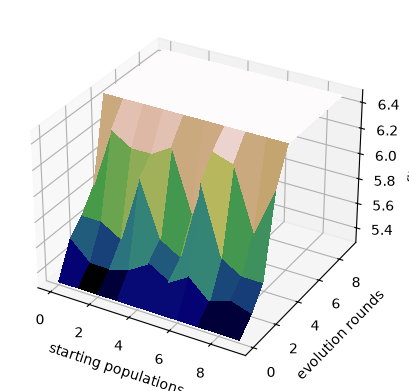

In [23]:
N = 10
K = 0
A = 2
r = 10
p = 10

boob, ass, dick, ratioed = one_mutant_scape(N,K,A, rounds = r, players = p)
boobs = generate_onescape(boob, ass)

## K = N-1 : Fully Random Fitness Landscape
The largest possible value of K is N-1 (every gene is dependent on every other gene in determining its fitness contribution)
A fitness landscape of this kind is entirely uncorrelated, that is nearby genotypes are not likely to have similar fitness values. We refer to this as a rugged fitness landscape. A rugged fitness landscape has the following properties:
- number of local optima is very large:
    - if we were to rank all genomes from lowest fitness (1) to highest fitness ($2^N$), the probability $P_m$ that any genotype is at a local optima, is the probability that it is the highest value of all it's one-distance neighbours:
        - $P_m = \frac{1}{N+1}$
    - the total number of such optima $M1$:
        - $M1 = \frac{2^N}{N+1}$
        - can be generalized to $A$ instead of two as:
            - $M1 = \frac{A^N}{D+1}$ 
    - what if we did r-mutant walks (that is we can jump multiple mutant steps at a time):
        -  $\displaystyle\sum_{j=0}^{r}($ $^{N}_{j})$ = $\displaystyle\sum_{j=0}^{r}\frac{N!}{j!(N-j)!}$
        -  we are not modelling this fuck you for asking
- the expected number of fitter one-mutant neighbours dwindles by half at each improvement step
- walks to the local optima are short and vary as a logarithmic function of N
    - to obtain an upper bound on walk lengths, consider the lowest rank genotype, because we expect to step by half the expected relative rank of a genotype $x$ in comparison to the top genome $T$ after $r$ steps is:
        - $\frac{x}{T} = \frac{2^r-1}{2^r}$
    - therefore the probability we are at a local optimum $P_m$ is:
        - $P_m = (\frac{x}{T})^{D-1}$
        - we modify the above slightly when x and T are very small
            - $P_m = \frac{(x-1)!(T-D-1)!}{(T-1)!(x-D-1)!}$   
    - combining the equations for relative rank and probability, we can calculate the probability that we will encounter a local optima in l steps:
        - $P_l = \displaystyle\prod_{r=0}^{l}[1 - \frac{2^{r} - 1}{2^{r}}^{D-1}]$
        - this $P_l$ decreases as $l$ grows
        - if we set $r = log_2(D-1)$ then:
            - $P_l = 1 - (1-\frac{1}{(D-1)^{D-1}})$
            - this is well approximated by: $1-\frac{1}{e} = 0.63$
        - thus we can approximate the length of the walk that gets us a 63% chance of hitting the optima with:
            - $r \approx ln(D-1)$   
- the expected time $t_{op}$ to reach the optimum is proportional to the dimensionality $D$ of the space
    - since the adaptive walk steps halfway to the top rank at each improvement step, the expected waiting time to find a fitter variant doubles after each improvement step
    - given the above expected length of the walk $r$ the expected waiting time (number of tried mutations) is:
        - $t_{op} = \displaystyle\sum_{l=0}^{log_{2}(D-1) - 1}2^l$   
- the expected ratio of accepted to tried mutations should scale with:
    - $ln(N)/N$
- any genome can climb to only a small fraction of the local optima
    - if we assume starting from the lowest ranked genotype, we can generate a maximal estimate for the maximal number of branches to fitter variants: all D of its neighbours
    - assuming that on average after a single improvement step, we are halfway to a local optima: (D-1)2 , that is almost half of the neighbours are fitter
    - after successive steps: D/4 -> D/8 -> D/16.... D/D
    - given the expected walk length of $r = log_2(D-1)$ we can model the gross upper bound on the expected number of alternative optima accessible from the lowest ranked entity as:
        - $\frac{D^{log_{2}D}}{2^{(log_{2}D)(log_{2}D-1)/2}}$
        - $= \frac{D^{(log_{2}D}}{D^{(log_{2}D+1)/2}}$
        - $= D^{(log_{2}D\hspace{0.5cm}1)/2}$???????
        - no fucking clue about this one. No I will not be attempting to verify it
        - try and find paper on this
    - this is an overestimation because it ignores possible walk convergences
- a small fraction of genotypes can climb to any one optimum
    - the dual of our last point, the number of genotypes that can reach any one optima:
        - $\displaystyle\sum_{i=1}^{log_{2}D}D^{i}2^{-(i)(i-1)/2}$
        - assume $N=256$ and $A=2$, number of genotypes is $2^{256}$ or $10^{77}$ but only $10^9$ can reach the global optima  

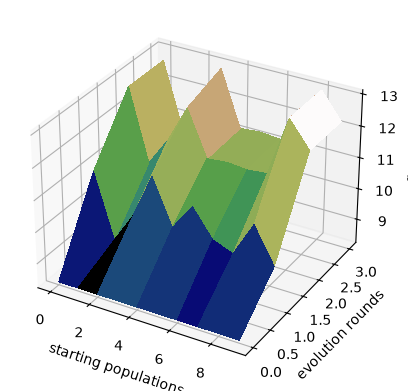

The probability of being a local optimum is: 0.047619047619047616
The expected number of local optima we could run into here is: 295.0952380952381
The probability of running into a local optima only by the end is 0.9170086831167777
There is a 63% chance we hit a local optima in 4.247927513443585 steps
The expected waiting time to an optima is 15
The expected ratio for accepted to tried mutations is 0.14978661367769955
An actual ratio observed with one of the players is 0.04878048780487805


In [24]:
N = 20
K = 19
A = 2
r = 4
p = 10

boobs, asses, penus, ratioed = one_mutant_scape(N,K,A, rounds = r, players = p)
boobies = generate_onescape(boobs, asses)

# The probability of being a local optima:
Pm = 1/(N+1)

# The number of local optima(total):
M1 = (2**N)*Pm

#The proportion of local optima in our particular path:
pM1 = (len(penus)/(2**N))*M1

# The expected relative rank of our genotypes at the end:
x_T = ((2**r) - 1)/(2**r)

# The probability of encountering a local optimum only at the end of our walk
P_l = 1
i = np.arange(1,r)
factors = 1 - (((2**i) - 1)/2**i)**(N-1)
P_l *=  np.prod(factors) 

# the expected length of our walk until hitting the local optima (63% chance to hit) is:
r_e = math.log2(N-1)

# the expected wait for our optima is:
t_op = 0
l = np.arange(int(r_e))
factors_sum = 2**l
t_op += np.sum(factors_sum)

# the expected ratio of accepted:tried mutations is:
e_ratio = math.log(N)/N
# our number is off from this estimation unsure why


print(f"The probability of being a local optimum is: {Pm}")
print(f"The expected number of local optima we could run into here is: {pM1}")
print(f"The probability of running into a local optima only by the end is {P_l}")
print(f"There is a 63% chance we hit a local optima in {r_e} steps")
print(f"The expected waiting time to an optima is {t_op}")
print(f"The expected ratio for accepted to tried mutations is {e_ratio}")
print(f"An actual ratio observed with one of the players is {ratioed[0]}")

### The Complexity Catastrophe
- novel complextiy catastrophe limits the power of selection in leading a population around the genotype space
    - consequence of attempting to optimize a system with an increasing number of conflicting constraints
    - the conflicting constraints best mutual choices of alleles tends to be poorer (than the $K=0$ situation) as $K \to N -1$  


In [25]:
# Here we're testing the guassian distribution of the fitness frequencies of fitnesses made from the extreme U-shaped weight distribution
# This generates weights in the ensemble from an extreme U-shaped distribution, where the weight is either 1 or 0
def weights_extreme(N: int,
                    K: int,
                    ensemble: dict,
                    A: int = 2):
    weights = {}
    K_loci = hp.assign_neighbours(N,K)
    for i in range(N):
        weight_i = []
        neighbours = K_loci[i]
        neighbour_set = {}
        for j in ensemble.keys():
            genotype = ensemble[j]
            temp = []
            present = False
            for n in neighbours:
                temp.append(genotype[n])
            for key, val in neighbour_set.items():
                if val == temp:
                    weight_i.append(key)
                    present = True
            if present == False:
                weight = rd.randint(0,1)
                neighbour_set[weight] = temp
                weight_i.append(weight)
            elif present == True:
                present = False
            weights[i] = weight_i
    return weights

N = 20
K = 19
A = 2

ensemble = hp.generate_ensemble(N, A)
weights = weights_extreme(N, K, ensemble, A)
fitnesses = calculate_fitness(weights, ensemble)

def sort

def fitness_frequencies(fitness: list):
    fitness_list = []
    frequencies_list = []
    
                
        

